In [84]:
import talib
from tvDatafeed import TvDatafeed, Interval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [85]:
tv = TvDatafeed()
data = tv.get_hist('TATASTEEL', 'NSE', interval=Interval.in_daily, n_bars = 5000) # For last trading day

In [86]:
data = data[['open', 'high', 'low', 'close']]

In [87]:
close_prices = data['close'].to_numpy()
X = np.zeros((4990, 10))
Y = np.zeros((4990, 1))

In [88]:
for i in range(4990):
    X[i] = close_prices[i:i+10]
    Y[i] = close_prices[i+10]

In [89]:
x_train = X[:4000]
y_train = Y[:4000]
x_test = X[4000:]
y_test = Y[4000:]

In [90]:
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization #type:ignore

In [91]:
model = Sequential()

model.add(LSTM(100, activation='tanh', return_sequences=True, input_shape=(10, 1)))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(LSTM(100, activation='tanh', return_sequences=True))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(LSTM(50, activation='tanh'))
model.add(Dropout(0.2))
model.add(BatchNormalization())

model.add(Dense(1, activation='linear'))

/home/mradul-001/.local/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [92]:
model.compile(
    loss = 'mean_squared_error',
    optimizer = 'adam',
)

In [93]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_17 (LSTM)                  │ (None, 10, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 10, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 10, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 10, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 10, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 10, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,451 (595.51 KB)

 Trainable params: 151,951 (593.56 KB)

 Non-trainable params: 500 (1.95 KB)

In [94]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1830.9174 - val_loss: 10741.5771
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1589.8363 - val_loss: 7449.6851
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1178.4880 - val_loss: 4812.6509
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 710.0708 - val_loss: 2543.6631
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 326.4002 - val_loss: 1691.9343
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 107.4898 - val_loss: 1362.5879
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 36.9442 - val_loss: 1123.1565
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 23.3923 - val_loss: 1428.1549
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 18.6267 - val_loss: 1021.5009
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 19.9062 - val_loss: 1025.7417


In [95]:
prediction = model.predict(x_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


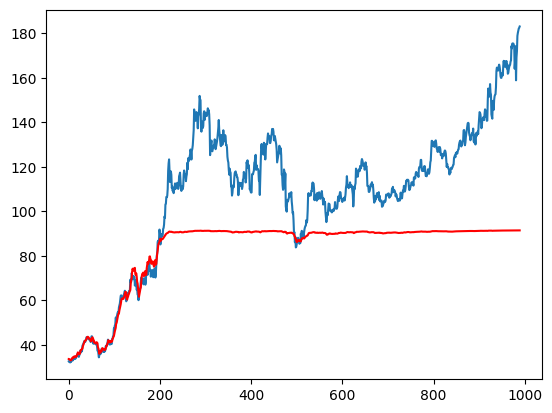

In [96]:
plt.plot([i for i in range(990)], y_test)
plt.plot([i for i in range(990)], prediction, c = 'red')
plt.show()

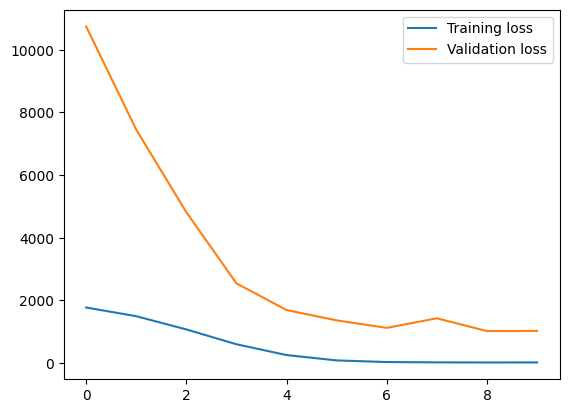

In [97]:
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.legend()
plt.show()